In [1]:
# Testand
import sys
print(sys.path)

['C:\\Users\\Guilherme\\AppData\\Local\\Programs\\Python\\Python313\\python313.zip', 'C:\\Users\\Guilherme\\AppData\\Local\\Programs\\Python\\Python313\\DLLs', 'C:\\Users\\Guilherme\\AppData\\Local\\Programs\\Python\\Python313\\Lib', 'C:\\Users\\Guilherme\\AppData\\Local\\Programs\\Python\\Python313', 'c:\\Users\\Guilherme\\Desktop\\Projeto\\modelagem\\.venv', '', 'c:\\Users\\Guilherme\\Desktop\\Projeto\\modelagem\\.venv\\Lib\\site-packages']


# Parte 1 — Preparação da Base (Gold no nível de aluno)

**Tech Challenge — Fase 3 (Pós-Tech Data Analytics)**

O desafio pede um modelo supervisionado que prevê se um aluno será
alfabetizado ou não, usando a camada Gold construida na Fase 2.

Só que a Gold da Fase 2 foi feita para dashboards: as três tabelas que
ela gera são todas agregadas por município, assim não existe uma
linha por aluno la.

Este notebook parte da camada Silver (que tem a granularidade certa), cria uma
Gold nova, especifica para modelagem:

1. Uma variável que vaza o target (`proficiencia`) — q precisa ser
   excluida das features.
2. Como trazer contexto do município/UF sem vazar o resultado do ano
   que estamos tentando prever.


## 1. Setup

Importamos as funções de `src/processing/gold/construir_gold_alunos.py`.


In [2]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))

from src.processing.gold.construir_gold_alunos import (
    carregar_silver,
    carregar_bronze_latest,
    preparar_base_aluno,
    contexto_defasado,
    construir_gold_alunos,
    PREFIXO_UF,
)
from src.utils.paths import GOLD_DIR

pd.set_option("display.max_columns", 50)


## 2. Carregar o Silver e olhar a granularidade

A Silver `alfabetizacao_integrado.parquet` já tem uma linha por aluno, daqui que partim para a Gold de modelagem.


In [3]:
silver = carregar_silver()
n_linhas_silver = len(silver)
print(f"{n_linhas_silver:,} linhas, {silver.shape[1]} colunas")
silver.head()


3,867,999 linhas, 15 colunas


,ano,id_municipio,id_municipio_nome,id_escola,id_aluno,caderno,serie,rede,presenca,preenchimento_caderno,alfabetizado,proficiencia,peso_aluno,_ingestion_date,_source
0,2024,3204906,São Mateus,60022379,32028878,43,2° ano do Ensino Fundamental,Municipal,Ausente,Prova não preenchida,Não,NaN,NaN,2026-07-13,basedosdados_batch
1,2024,3205309,Vitória,60022713,32007513,43,2° ano do Ensino Fundamental,Municipal,Presente,Prova preenchida,Sim,786.93,1.09,2026-07-13,basedosdados_batch
2,2023,1302603,Manaus,60000703,13024170,1,2° ano do Ensino Fundamental,Estadual,Ausente,Prova não preenchida,Não,NaN,NaN,2026-07-13,basedosdados_batch
3,2023,1501808,Breves,60001609,15031556,1,2° ano do Ensino Fundamental,Municipal,Ausente,Prova não preenchida,Não,NaN,NaN,2026-07-13,basedosdados_batch
4,2023,1502806,Curralinho,60001620,15041830,1,2° ano do Ensino Fundamental,Municipal,Ausente,Prova não preenchida,Não,NaN,NaN,2026-07-13,basedosdados_batch


In [4]:
silver.dtypes


ano                        Int64
id_municipio              object
id_municipio_nome         object
id_escola                 object
id_aluno                  object
caderno                   object
serie                     object
rede                      object
presenca                  object
preenchimento_caderno     object
alfabetizado              object
proficiencia             float64
peso_aluno               float64
_ingestion_date           object
_source                   object
dtype: object

## 3. O problema: `proficiencia` vaza o target

`alfabetizado` (Sim/Não) é o que queremos prever.  
Hipotese: será que ele já não está escondido em alguma outra coluna?  
Comparando `proficiencia` entre as duas classes.


In [5]:
resumo = silver.groupby("alfabetizado")["proficiencia"].describe()
resumo


,count,mean,std,min,25%,50%,75%,max
alfabetizado,,,,,,,,
Não,1370115.0,702.815497,31.255528,578.46,681.824417,709.522218,729.443616,742.999819
Sim,1984546.0,779.837129,27.026391,743.00,758.968619,774.333107,794.690000,904.382031


In [6]:
minimo_sim = silver.loc[silver["alfabetizado"] == "Sim", "proficiencia"].min()
maximo_nao = silver.loc[silver["alfabetizado"] == "Não", "proficiencia"].max()

print(f"Menor proficiencia entre os 'Sim': {minimo_sim:.4f}")
print(f"Maior proficiencia entre os 'Não': {maximo_nao:.4f}")


Menor proficiencia entre os 'Sim': 743.0000
Maior proficiencia entre os 'Não': 742.9998


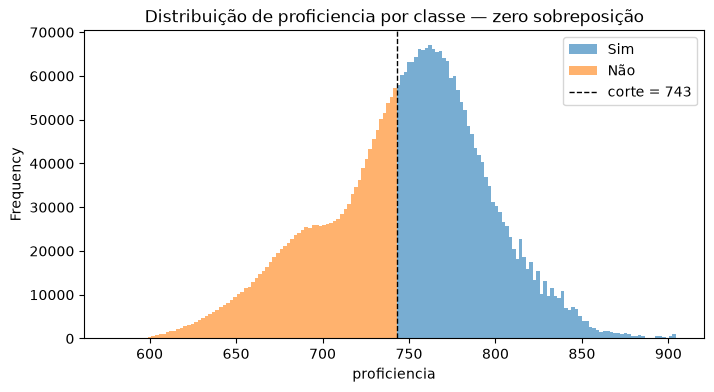

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
silver.loc[silver["alfabetizado"] == "Sim", "proficiencia"].plot(
    kind="hist", bins=80, alpha=0.6, label="Sim", ax=ax
)
silver.loc[silver["alfabetizado"] == "Não", "proficiencia"].plot(
    kind="hist", bins=80, alpha=0.6, label="Não", ax=ax
)
ax.axvline(743, color="black", linestyle="--", linewidth=1, label="corte = 743")
ax.set_xlabel("proficiencia")
ax.set_title("Distribuição de proficiencia por classe — zero sobreposição")
ax.legend()
plt.show()


Conclusão: As duas distribuições não se sobrepõem, existe um corte em ~743 pontos que separa `alfabetizado = Sim` de
`alfabetizado = Não`. Ou seja, `alfabetizado` foi derivado de `proficiencia` por esse threshold.

Se `proficiencia` entrar como feature, o modelo não aprende nada,  
vira um classificador de limiar disfarçado de Machine Learning.  
Precisamos tratar esse data leakage que o desafio pede
Ou seja, `proficiencia` sai do conjunto de features.
Podemos também remover `serie`que é constante (todas as linhas são 2o ano do Ensinao Fundamental)


In [8]:
silver["serie"].value_counts()


serie
2° ano do Ensino Fundamental    3867999
Name: count, dtype: int64

## 4. Trazendo dados do município e da UF sem vazar informação

Queremos adicionar informações do município e do estado como contexto  
para o modelo (exempl: taxa de alfabetização histórica da região).

O problema: se usarmos o dado do mesmo ano que estamos tentando  
prever, isso vaza informação porque esse indicador do município já é  
calculado em cima dos próprios alunos que queremos prever.

Solução: usar o dado do ano anterior. Cada aluno recebe o
indicador do seu município referente a um ano antes do resultado dele
existir. Dessa maneira usamos uma informação histórica real, não uma "resposta
disfarçada".

In [9]:
municipio = carregar_bronze_latest("municipio")
municipio[["id_municipio", "ano", "rede", "taxa_alfabetizacao", "media_portugues"]].head()


,id_municipio,ano,rede,taxa_alfabetizacao,media_portugues
0,1100031,2023,Municipal,69.10,767.8763
1,1100072,2023,Municipal,58.20,747.8918
2,1100189,2023,Pública (Estadual e Municipal),69.73,762.4062
3,1101609,2023,Municipal,50.70,745.6802
4,1101807,2023,Municipal,55.69,752.3724


Um detalhe que só percebemos ao olhar os dados de perto: a tabela do
município tem mais de uma linha para o mesmo município e ano... Uma para
cada tipo de rede de ensino (Municipal, Estadual, etc). Se juntássemos
direto pelo município e ano, cada aluno apareceria duplicado várias
vezes na base.

Para evitar isso, o merge também usa a rede do próprio aluno como
critério de junção, além do ano anterior. Assim cada aluno recebe só a
linha de contexto certa, sem duplicar.

In [10]:
ctx_municipio = contexto_defasado(
    municipio, ["id_municipio", "ano"], "_municipio_ano_anterior"
)
print("Duplicatas na chave id_municipio+ano+rede:",
      ctx_municipio.duplicated(subset=["id_municipio", "ano", "rede"]).sum())
ctx_municipio.head()


Duplicatas na chave id_municipio+ano+rede: 0


,id_municipio,ano,rede,taxa_alfabetizacao_municipio_ano_anterior,media_portugues_municipio_ano_anterior
0,1100031,2024,Municipal,69.10,767.8763
1,1100072,2024,Municipal,58.20,747.8918
3,1101609,2024,Municipal,50.70,745.6802
4,1101807,2024,Municipal,55.69,752.3724
5,1302900,2024,Municipal,53.17,731.0744


## 5. Construindo a base final

Juntamos: Silver já preparado (sem `proficiencia`/`serie`) + contexto
defasado de município + contexto defasado de UF + metas oficiais de
alfabetização (essas sim, seguras no mesmo ano, são metas de governo
fixadas previamente, não derivadas do resultado observado).

Reaproveitamos o `silver` e o `municipio` que já estão carregados acima em
vez de recarregar tudo do zero, evita manter duas cópias de uma tabela
de quase 4 milhões de linhas na memória ao mesmo tempo.


In [11]:
import gc

base = preparar_base_aluno(silver)

uf = carregar_bronze_latest("uf")
ctx_uf = contexto_defasado(uf, ["sigla_uf", "ano"], "_uf_ano_anterior")

meta_municipio = carregar_bronze_latest("meta_alfabetizacao_municipio")
meta_municipio["id_municipio"] = meta_municipio["id_municipio"].astype(str).str.strip().str.zfill(7)
colunas_meta = [c for c in meta_municipio.columns if c.startswith("meta_alfabetizacao_")]
meta_municipio_reduzida = meta_municipio[["id_municipio", "ano"] + colunas_meta].drop_duplicates()

meta_uf = carregar_bronze_latest("meta_alfabetizacao_uf")
meta_uf_reduzida = (
    meta_uf[["sigla_uf", "ano"] + colunas_meta]
    .drop_duplicates()
    .rename(columns={c: f"{c}_uf" for c in colunas_meta})
)

# liberamos o que nao precisamos mais antes do merge final
del silver, municipio, uf, meta_municipio, meta_uf
gc.collect()

gold_alunos = (
    base
    .merge(ctx_municipio, on=["id_municipio", "ano", "rede"], how="left")
    .merge(ctx_uf, on=["sigla_uf", "ano", "rede"], how="left")
    .merge(meta_municipio_reduzida, on=["id_municipio", "ano"], how="left")
    .merge(meta_uf_reduzida, on=["sigla_uf", "ano"], how="left")
)

print(f"{len(gold_alunos):,} linhas, {gold_alunos.shape[1]} colunas")
gold_alunos.head()


3,867,999 linhas, 30 colunas


,ano,id_municipio,id_escola,id_aluno,caderno,rede,presenca,preenchimento_caderno,alfabetizado,peso_aluno,sigla_uf,alfabetizado_flag,taxa_alfabetizacao_municipio_ano_anterior,media_portugues_municipio_ano_anterior,taxa_alfabetizacao_uf_ano_anterior,media_portugues_uf_ano_anterior,meta_alfabetizacao_2024,meta_alfabetizacao_2025,meta_alfabetizacao_2026,meta_alfabetizacao_2027,meta_alfabetizacao_2028,meta_alfabetizacao_2029,meta_alfabetizacao_2030,meta_alfabetizacao_2024_uf,meta_alfabetizacao_2025_uf,meta_alfabetizacao_2026_uf,meta_alfabetizacao_2027_uf,meta_alfabetizacao_2028_uf,meta_alfabetizacao_2029_uf,meta_alfabetizacao_2030_uf
0,2024,3204906,60022379,32028878,43,Municipal,Ausente,Prova não preenchida,Não,NaN,ES,0,67.19,751.3222,67.52,753.1398,69.26,71.26,73.18,75.01,76.76,78.43,80.0,69.9,71.8,73.6,75.3,76.9,78.5,80.0
1,2024,3205309,60022713,32007513,43,Municipal,Presente,Prova preenchida,Sim,1.09,ES,1,65.88,751.3438,67.52,753.1398,68.18,70.39,72.51,74.54,76.46,78.28,80.0,69.9,71.8,73.6,75.3,76.9,78.5,80.0
2,2023,1302603,60000703,13024170,1,Estadual,Ausente,Prova não preenchida,Não,NaN,AM,0,NaN,NaN,NaN,NaN,56.80,61.28,65.58,69.63,73.41,76.87,80.0,56.8,61.3,65.6,69.6,73.4,76.9,80.0
3,2023,1501808,60001609,15031556,1,Municipal,Ausente,Prova não preenchida,Não,NaN,PA,0,NaN,NaN,NaN,NaN,49.78,55.57,61.21,66.57,71.53,76.02,80.0,53.6,58.7,63.6,68.2,72.5,76.5,80.0
4,2023,1502806,60001620,15041830,1,Municipal,Ausente,Prova não preenchida,Não,NaN,PA,0,NaN,NaN,NaN,NaN,32.28,40.46,49.20,58.00,66.31,73.73,80.0,53.6,58.7,63.6,68.2,72.5,76.5,80.0


## 6. Validação

Três checagens antes de seguir para a EDA (Parte 2):
1. O número de linhas bate com o Silver original (nenhum aluno foi
   duplicado ou perdido nos merges).
2. `proficiencia` não está mais presente.
3. O target continua balanceado.


In [12]:
assert len(gold_alunos) == n_linhas_silver, "Numero de linhas mudou -- merge duplicou ou perdeu alunos"
assert "proficiencia" not in gold_alunos.columns, "Coluna vazada ainda presente"
print("OK: sem duplicacao de linhas e sem a coluna vazada.")

gold_alunos["alfabetizado_flag"].value_counts(normalize=True)


OK: sem duplicacao de linhas e sem a coluna vazada.


alfabetizado_flag
1    0.513068
0    0.486932
Name: proportion, dtype: float64

In [13]:
cols_contexto = [c for c in gold_alunos.columns if "ano_anterior" in c]
cobertura_por_ano = gold_alunos.groupby("ano")[cols_contexto[0]].apply(
    lambda s: f"{(1 - s.isnull().mean()) * 100:.1f}% preenchido"
)
cobertura_por_ano


ano
2023     0.0% preenchido
2024    97.9% preenchido
Name: taxa_alfabetizacao_municipio_ano_anterior, dtype: object

Como esperado: alunos de 2023 ficam sem contexto histórico (não existe
"ano anterior" nos dados — a coleta começa em 2023), enquanto 2024 tem
~98% de cobertura. Isso é um `NaN` justo, vamos tratá-lo
como imputação de valores faltantes depois.


## 7. Salvar

Obs: A base fica em `data/gold/base_alunos_modelagem.parquet` fora do git.


In [14]:
caminho = GOLD_DIR / "base_alunos_modelagem.parquet"
gold_alunos.to_parquet(caminho, index=False)
print(f"Salvo em: {caminho}")


Salvo em: C:\Users\Guilherme\Desktop\Projeto\modelagem\data\gold\base_alunos_modelagem.parquet
